## 1. Setup and Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from omegaconf import OmegaConf
from collections import defaultdict

from segment_anything import SamPredictor, sam_model_registry
from segment_anything.modeling.image_encoder import Attention as EncoderSamAttention
from segment_anything.modeling.transformer import Attention as DecoderAttention
from train.segment_anything_training.modeling.image_encoder import Attention as EncoderAttentionTraining
from seginw.segment_anything.modeling.image_encoder import Attention as EncoderAttention

from processors import get_encoder_processor
from sam_engine import Engine, override_args

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("All imports successful!")

/pfss/mlde/workspaces/mlde_wsp_IAS_SAMMerge/SAM_Quantization/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/pfss/mlde/workspaces/mlde_wsp_IAS_SAMMerge/SAM_Quantization/.venv/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/pfss/mlde/workspaces/mlde_wsp_IAS_SAMMerge/SAM_Quantization/.venv/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/pfss/mlde/workspaces/mlde_wsp_IAS_SAMMerge

All imports successful!


## 2. Configuration

In [2]:
# Configuration parameters
CONFIG_FILE = 'quant/config/hq44k/rtn.yaml'
PROCESSOR_NAME = 'ATTN_MAP_COLLECTOR'
PERCENT_ENTROPY = 0.3  # Percentage of heads to prune based on entropy
NUM_CALIB_SAMPLES = 4  # Number of calibration samples
OUTPUT_DIR = './entropy_plots'
MODEL_TYPE = 'vit_l'
CHECKPOINT_PATH = './ckts/sam_hq_vit_l.pth'

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Configuration:")
print(f"  Processor: {PROCESSOR_NAME}")
print(f"  Percent Entropy: {PERCENT_ENTROPY}")
print(f"  Calibration Samples: {NUM_CALIB_SAMPLES}")
print(f"  Output Directory: {OUTPUT_DIR}")

Configuration:
  Processor: ATTN_MAP_COLLECTOR
  Percent Entropy: 0.3
  Calibration Samples: 4
  Output Directory: ./entropy_plots


## 3. Load Configuration and Model

In [3]:
# Load config
config = OmegaConf.load(CONFIG_FILE)
config.quantization.percent_entropy = PERCENT_ENTROPY
config.quantization.high_entropy = True

print("Config loaded:")
print(OmegaConf.to_yaml(config.quantization))

# Initialize model
print(f"\nLoading {MODEL_TYPE} model from {CHECKPOINT_PATH}...")
sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH).to('cuda')
predictor = SamPredictor(sam)
print("Model loaded successfully!")

Config loaded:
quandecoder: false
quanrtn: true
low_high_density: none
quangptq: false
quansmooth: false
quanro: false
rtn_cuda: false
gptq_cuda: false
act_scales_file: ./ckts/sam_vit_lactivation_scales.pt
act_quant: per_token
weight_quant: per_channel
n_bits: 4
n_bits_mlp: 4
quantize_output: false
up_down_RTN: none
qkT_v: true
channel: false
percent: 100
centerQ: false
percent_entropy: 0.3
percent_entropy_global: 0.145
high_entropy: true
prune_global: true


Loading vit_l model from ./ckts/sam_hq_vit_l.pth...


/pfss/mlde/workspaces/mlde_wsp_IAS_SAMMerge/SAM_Quantization/sam-hq/segment_anything/build_sam.py:162: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(

<All keys matched successfully>
Model loaded successfully!


## 4. Initialize Engine and Processor

In [4]:
# Initialize engine
print("Initializing engine...")
engine = Engine('entropy_viz', quantize_encoder=True, quantize_decoder=False)

# Get processor
print(f"\nInitializing {PROCESSOR_NAME} processor...")
processor = get_encoder_processor(PROCESSOR_NAME)

# Set up processor
# processor.set_dataloaders(engine.dataloaders)
# processor.set_accelerator(engine.accelerator)
processor.set_params(config)

print(f"Processor initialized: {processor.strategy_name}")
print(f"  Percent: {processor.percent}")
print(f"  Prune high entropy: {processor.prunehighentropy}")

Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Initializing engine...
------------------------------ valid --------------------------------
--->>> valid  dataset  0 / 1   DIS5K-TR <<<---
-im- DIS5K-TR ./data/DIS5K/DIS-TR/im :  3000
-gt- DIS5K-TR ./data/DIS5K/DIS-TR/gt :  3000

Initializing ATTN_MAP_COLLECTOR processor...
------------------------------ valid --------------------------------
--->>> valid  dataset  0 / 1   DIS5K-VD <<<---
-im- DIS5K-VD ./data/DIS5K/DIS-VD/im :  470
-gt- DIS5K-VD ./data/DIS5K/DIS-VD/gt :  470
Processor initialized: ATTN_MAP_COLLECTOR
  Percent: 0.5
  Prune high entropy: True


## 5. Calibrate Processor to Collect Entropy Statistics

In [5]:
print(f"\n{'='*80}")
print(f"Calibrating {PROCESSOR_NAME} with {NUM_CALIB_SAMPLES} samples...")
print(f"{'='*80}\n")

processor.calibrate(
    predictor=predictor,
    modules=(DecoderAttention, EncoderAttentionTraining, EncoderAttention, EncoderSamAttention),
    num_samples=NUM_CALIB_SAMPLES
)

print("\n" + "="*80)
print("Calibration complete!")
print("="*80)


Calibrating ATTN_MAP_COLLECTOR with 4 samples...

Registering attention hook for blocks.0.attn
Registering attention hook for blocks.1.attn
Registering attention hook for blocks.2.attn
Registering attention hook for blocks.3.attn
Registering attention hook for blocks.4.attn
Registering attention hook for blocks.5.attn
Registering attention hook for blocks.6.attn
Registering attention hook for blocks.7.attn
Registering attention hook for blocks.8.attn
Registering attention hook for blocks.9.attn
Registering attention hook for blocks.10.attn
Registering attention hook for blocks.11.attn
Registering attention hook for blocks.12.attn
Registering attention hook for blocks.13.attn
Registering attention hook for blocks.14.attn
Registering attention hook for blocks.15.attn
Registering attention hook for blocks.16.attn
Registering attention hook for blocks.17.attn
Registering attention hook for blocks.18.attn
Registering attention hook for blocks.19.attn
Registering attention hook for blocks.2

After sample 1: blocks.0.attn.head_0 has 1 entropy values


After sample 2: blocks.0.attn.head_0 has 2 entropy values


After sample 3: blocks.0.attn.head_0 has 3 entropy values



Calibration complete!


## 6. Extract Entropy Statistics

In [6]:
def extract_entropy_statistics(processor):
    """Extract entropy statistics from calibrated processor."""
    if not hasattr(processor, 'entropy_stats'):
        print("Warning: Processor has no entropy_stats attribute")
        return {}

    print(f"\nExtracting entropy statistics from {processor.strategy_name}...")
    print(f"Found {len(processor.entropy_stats)} head entries")

    # Group by layer and head
    layer_head_entropy = {}

    for head_key, entropy_values in processor.entropy_stats.items():
        if len(entropy_values) == 0:
            continue

        # Parse key format: 'blocks.22.attn.head_233'
        parts = head_key.split('.')
        if len(parts) < 4:
            continue

        block_idx = int(parts[1])
        head_idx = int(parts[3].split('_')[1])

        # Calculate mean entropy
        entropy_tensor = torch.tensor(entropy_values) if not isinstance(entropy_values[0], torch.Tensor) else torch.stack(entropy_values)
        mean_entropy = torch.mean(entropy_tensor).item()

        layer_name = f"Block {block_idx}"
        if layer_name not in layer_head_entropy:
            layer_head_entropy[layer_name] = {}

        layer_head_entropy[layer_name][head_idx] = mean_entropy

    print(f"Organized into {len(layer_head_entropy)} layers")
    return layer_head_entropy


def extract_pruning_masks(processor):
    """Extract pruning masks from calibrated processor."""
    if not hasattr(processor, 'final_entropy_stats'):
        print("Warning: Processor has no final_entropy_stats attribute")
        return {}

    print(f"\nExtracting pruning masks...")
    print(f"Found {len(processor.final_entropy_stats)} layers with masks")

    masks = {}
    for layer_name, mask_data in processor.final_entropy_stats.items():
        # Convert layer name format
        parts = layer_name.split('.')
        if 'blocks' in parts:
            block_idx = int(parts[parts.index('blocks') + 1])
            simple_name = f"Block {block_idx}"
            masks[simple_name] = mask_data

    return masks


# Extract statistics
layer_head_entropy = extract_entropy_statistics(processor)
pruning_masks = extract_pruning_masks(processor)

if not layer_head_entropy:
    print("\nError: No entropy statistics found!")
else:
    print(f"\nSuccessfully extracted entropy data for {len(layer_head_entropy)} layers")


Extracting entropy statistics from ATTN_MAP_COLLECTOR...
Found 384 head entries
Organized into 24 layers

Successfully extracted entropy data for 24 layers


In [7]:
attention_maps = processor.attention_maps if hasattr(processor, 'attention_maps') else None

In [8]:
len(processor.attention_maps['blocks.5.attn'])

4

In [9]:
processor

In [10]:
import numpy as np
import matplotlib.pyplot as plt






In [11]:
def select_extreme_heads(layer_head_entropy, block_idx):
    layer_name = f"Block {block_idx}"
    if layer_name not in layer_head_entropy:
        raise KeyError(f"Missing entropy stats for {layer_name}")
    head_entropy = layer_head_entropy[layer_name]
    max_head = max(head_entropy, key=head_entropy.get)
    min_head = min(head_entropy, key=head_entropy.get)
    return min_head, max_head, head_entropy


def plot_head_attention(attention_maps, block_idx, head_idx, sample_idx=0, agg="mean", cmap="magma", ax=None):
    layer_key = f"blocks.{block_idx}.attn"
    if layer_key not in attention_maps:
        raise KeyError(f"Missing attention maps for {layer_key}")
    attn_list = attention_maps[layer_key]
    if len(attn_list) == 0:
        raise ValueError(f"No attention maps stored for {layer_key}")

    attn = attn_list[sample_idx]  # (B, heads, N, N)
    attn = attn.mean(axis=0)  # average across batch -> (heads, N, N)
    head_attn = attn[head_idx]

    if agg is None:
        head_attn_agg = head_attn
    elif agg == "mean":
        head_attn_agg = head_attn.mean(axis=0)  # average over queries -> (N,)
    elif agg == "max":
        head_attn_agg = head_attn.max(axis=0)
    else:
        raise ValueError(f"Unsupported agg: {agg}")

    ax = ax or plt.gca()
    if agg is None:
        im = ax.imshow(np.log(head_attn_agg) , cmap=cmap)
        ax.set_title(f"Block {block_idx} | Head {head_idx} | raw N x N")
    else:
        n = head_attn_agg.shape[0]
        side = int(np.sqrt(n))
        if side * side != n:
            raise ValueError(f"Cannot reshape N={n} into square map")
        attn_map = head_attn_agg.reshape(side, side)
        im = ax.imshow(attn_map, cmap=cmap)
        ax.set_title(f"Block {block_idx} | Head {head_idx} | agg={agg}")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return head_attn_agg


def plot_attention_hist(attn_map, ax=None, bins=50):
    ax = ax or plt.gca()
    ax.hist(attn_map.flatten(), bins=bins, color="#4C72B0", alpha=0.9)
    ax.set_title("Attention histogram")
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")


def plot_raw_and_attention(raw_image, attention_maps, block_idx, head_idx, sample_idx=0, agg="mean", cmap="magma"):
    fig, axes = plt.subplots(1, 3, figsize=(11, 3))
    axes[0].imshow(raw_image)
    axes[0].set_title("Raw image")
    axes[0].axis("off")

    attn_map = plot_head_attention(attention_maps, block_idx, head_idx, sample_idx=sample_idx, agg=agg, cmap=cmap, ax=axes[1])
    plot_attention_hist(attn_map, ax=axes[2])
    fig.tight_layout()


In [12]:
layer_head_entropy[f'Block {block_idx}'].values()

NameError: name 'block_idx' is not defined

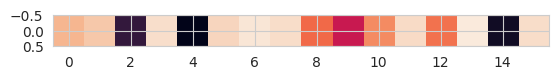

In [ ]:
block_idx = 6 
entropy = np.array(list(layer_head_entropy[f'Block {block_idx}'].values()))
plt.imshow(entropy.reshape(-1, 16))

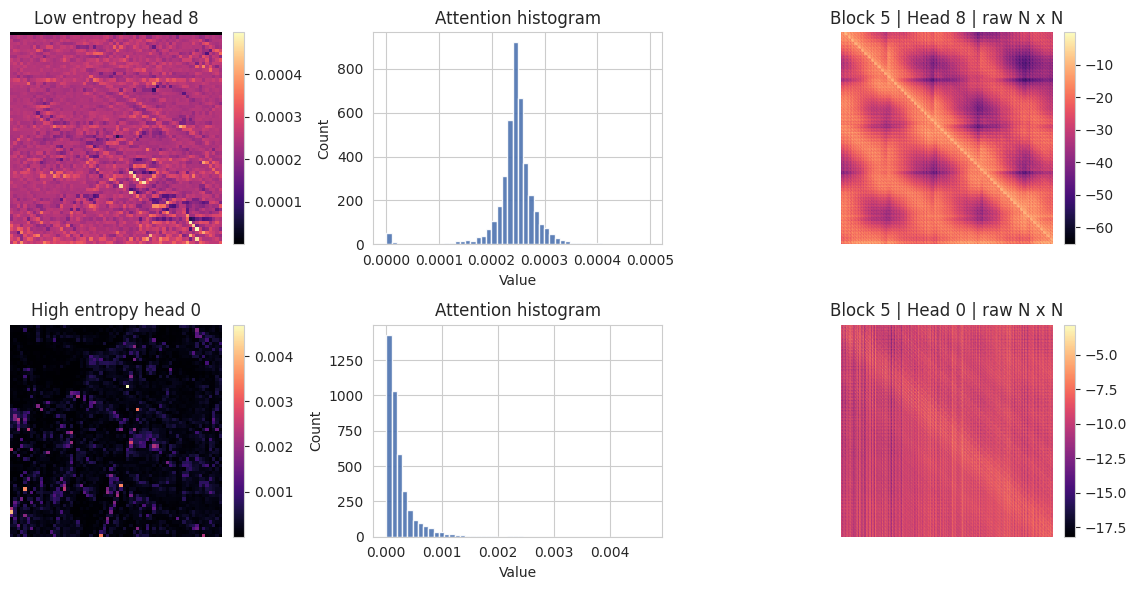

In [ ]:
# Pick a block and visualize the lowest/highest entropy heads
block_idx = 5 
low_head, high_head, _ = select_extreme_heads(layer_head_entropy, block_idx)

# Set raw_image to a numpy array (H, W, 3) if you want side-by-side plots.
# Example: raw_image = plt.imread('input_imgs/your_image.jpg')
raw_image = None

if raw_image is not None:
    plot_raw_and_attention(raw_image, attention_maps, block_idx, low_head, sample_idx=0, agg="mean")
    plot_raw_and_attention(raw_image, attention_maps, block_idx, high_head, sample_idx=0, agg="mean")
else:
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    attn_low = plot_head_attention(attention_maps, block_idx, low_head, sample_idx=0, agg="mean", ax=axes[0, 0])
    axes[0, 0].set_title(f"Low entropy head {low_head}")
    plot_attention_hist(attn_low, ax=axes[0, 1])
    plot_head_attention(attention_maps, block_idx, low_head, sample_idx=0, agg=None, ax=axes[0, 2])

    attn_high = plot_head_attention(attention_maps, block_idx, high_head, sample_idx=0, agg="mean", ax=axes[1, 0])
    axes[1, 0].set_title(f"High entropy head {high_head}")
    plot_attention_hist(attn_high, ax=axes[1, 1])
    plot_head_attention(attention_maps, block_idx, high_head, sample_idx=0, agg=None, ax=axes[1, 2])

    fig.tight_layout()
